# Preprocessing + Dataset Construction

## Objectives

1. Define the official split records
2. Build a memory-safe patch dataset
3. Normalize inputs correctly
4. Create S2-only and S2+DEM datasets
5. Verify everything visually before training

## Purpose
This notebook performs Step 2 of the project: preprocessing and dataset construction.

## Inputs
- Multispectral rasters from `multi/`
- DEM rasters from `dem/`
- Binary masks from `masks/`

## Outputs
- Train / validation / test scene records
- Patch indices
- PyTorch datasets for:
  - S2 only
  - S2 + DEM
- DataLoaders ready for model training

### Imports

In [1]:
import numpy as np
import torch
import rasterio
from torch.utils.data import Dataset, DataLoader
from rasterio.windows import Window, from_bounds, bounds as window_bounds
from rasterio.enums import Resampling
import colorsys
from pathlib import Path
import matplotlib.pyplot as plt

### Path Configuration

In [2]:
from pathlib import Path

cwd = Path.cwd()
print("Current working directory:", cwd)

candidate_dirs = [
    cwd / "FRS 2026. Floods Monitoring",
    cwd.parent / "FRS 2026. Floods Monitoring",
    cwd / "flood-segmentation" / "FRS 2026. Floods Monitoring",
    cwd.parent / "flood-segmentation" / "FRS 2026. Floods Monitoring",
]

DATA_DIR = None
for p in candidate_dirs:
    if p.exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find 'FRS 2026. Floods Monitoring'. "
        f"Tried: {[str(p) for p in candidate_dirs]}"
    )

MULTI_DIR = DATA_DIR / "multi"
DEM_DIR = DATA_DIR / "dem"
MASK_DIR = DATA_DIR / "masks"
OSM_DIR = DATA_DIR / "osm"

print("Resolved DATA_DIR :", DATA_DIR)
print("Multi dir exists  :", MULTI_DIR.exists())
print("DEM dir exists    :", DEM_DIR.exists())
print("Mask dir exists   :", MASK_DIR.exists())
print("OSM dir exists    :", OSM_DIR.exists())

Current working directory: c:\Users\wattd\OneDrive\Desktop\flood-segmentation
Resolved DATA_DIR : c:\Users\wattd\OneDrive\Desktop\flood-segmentation\FRS 2026. Floods Monitoring
Multi dir exists  : True
DEM dir exists    : True
Mask dir exists   : True
OSM dir exists    : True


### Define the suggested split

In [3]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class SceneRecord:
    scene_id: str
    multi_path: Path
    dem_path: Path
    mask_path: Path

train_records = [
    SceneRecord(
        scene_id="1_train",
        multi_path=MULTI_DIR / "1.tif",
        dem_path=DEM_DIR / "1_train.tif",
        mask_path=MASK_DIR / "1_train.tif",
    ),
    SceneRecord(
        scene_id="2_train",
        multi_path=MULTI_DIR / "2.tif",
        dem_path=DEM_DIR / "2_train.tif",
        mask_path=MASK_DIR / "2_train.tif",
    ),
]

val_records = [
    SceneRecord(
        scene_id="1_val",
        multi_path=MULTI_DIR / "1.tif",
        dem_path=DEM_DIR / "1_val.tif",
        mask_path=MASK_DIR / "1_val.tif",
    ),
    SceneRecord(
        scene_id="2_val",
        multi_path=MULTI_DIR / "2.tif",
        dem_path=DEM_DIR / "2_val.tif",
        mask_path=MASK_DIR / "2_val.tif",
    ),
]

test_records = [
    SceneRecord(
        scene_id=str(i),
        multi_path=MULTI_DIR / f"{i}.tif",
        dem_path=DEM_DIR / f"{i}.tif",
        mask_path=MASK_DIR / f"{i}.tif",
    )
    for i in range(3, 13)
]

print("Train scenes:", [r.scene_id for r in train_records])
print("Val scenes  :", [r.scene_id for r in val_records])
print("Test scenes :", [r.scene_id for r in test_records])

Train scenes: ['1_train', '2_train']
Val scenes  : ['1_val', '2_val']
Test scenes : ['3', '4', '5', '6', '7', '8', '9', '10', '11', '12']


### Check that all required files exist

In [4]:
def check_records(records, split_name):
    print(f"\nChecking {split_name} records")
    for r in records:
        print(
            r.scene_id,
            "| multi:", r.multi_path.exists(),
            "| dem:", r.dem_path.exists(),
            "| mask:", r.mask_path.exists()
        )

check_records(train_records, "train")
check_records(val_records, "val")
check_records(test_records, "test")


Checking train records
1_train | multi: True | dem: True | mask: True
2_train | multi: True | dem: True | mask: True

Checking val records
1_val | multi: True | dem: True | mask: True
2_val | multi: True | dem: True | mask: True

Checking test records
3 | multi: True | dem: True | mask: True
4 | multi: True | dem: True | mask: True
5 | multi: True | dem: True | mask: True
6 | multi: True | dem: True | mask: True
7 | multi: True | dem: True | mask: True
8 | multi: True | dem: True | mask: True
9 | multi: True | dem: True | mask: True
10 | multi: True | dem: True | mask: True
11 | multi: True | dem: True | mask: True
12 | multi: True | dem: True | mask: True


### Helper: read aligned full sample for one record

In [5]:
def read_aligned_full_sample(record: SceneRecord):
    # Read reference mask
    with rasterio.open(record.mask_path) as msk_src:
        mask = msk_src.read(1)
        ref_bounds = msk_src.bounds
        ref_height = msk_src.height
        ref_width = msk_src.width
        ref_transform = msk_src.transform
        ref_crs = msk_src.crs

    # Read DEM (already expected to match mask)
    with rasterio.open(record.dem_path) as dem_src:
        dem = dem_src.read(1)

    # Read multi aligned to the mask extent
    with rasterio.open(record.multi_path) as mul_src:
        assert mul_src.crs == ref_crs, "CRS mismatch between multi and mask"

        win = from_bounds(*ref_bounds, transform=mul_src.transform)
        win = win.round_offsets().round_lengths()

        multi = mul_src.read(
            window=win,
            out_shape=(mul_src.count, ref_height, ref_width),
            resampling=Resampling.bilinear
        )

    return multi, dem, mask

### Verify one train sample loads correctly

In [6]:
multi_train, dem_train, mask_train = read_aligned_full_sample(train_records[0])

print("Train sample shapes:")
print("Multi:", multi_train.shape)   # (bands, H, W)
print("DEM  :", dem_train.shape)     # (H, W)
print("Mask :", mask_train.shape)    # (H, W)
print("Mask unique values:", np.unique(mask_train))

Train sample shapes:
Multi: (10, 4971, 7442)
DEM  : (4971, 7442)
Mask : (4971, 7442)
Mask unique values: [0 1]


### Compute DEM normalization stats from training data only

In [7]:
train_dem_values = dem_train.astype(np.float32)

dem_mean = float(train_dem_values.mean())
dem_std = float(train_dem_values.std() + 1e-8)

print("DEM train mean:", dem_mean)
print("DEM train std :", dem_std)

DEM train mean: 151.59597778320312
DEM train std : 39.80539321899414


### Patch grid generator

In [8]:
def build_patch_index(records, patch_size=256, stride=256):
    patch_index = []

    for rec in records:
        with rasterio.open(rec.mask_path) as src:
            H, W = src.height, src.width

        for top in range(0, H, stride):
            for left in range(0, W, stride):
                h = min(patch_size, H - top)
                w = min(patch_size, W - left)

                patch_index.append({
                    "scene_id": rec.scene_id,
                    "multi_path": rec.multi_path,
                    "dem_path": rec.dem_path,
                    "mask_path": rec.mask_path,
                    "top": top,
                    "left": left,
                    "height": h,
                    "width": w
                })

    return patch_index

### Build patch indices

In [9]:
PATCH_SIZE = 256
STRIDE = 256

train_index = build_patch_index(train_records, patch_size=PATCH_SIZE, stride=STRIDE)
val_index = build_patch_index(val_records, patch_size=PATCH_SIZE, stride=STRIDE)
test_index = build_patch_index(test_records, patch_size=PATCH_SIZE, stride=STRIDE)

print("Train patches:", len(train_index))
print("Val patches  :", len(val_index))
print("Test patches :", len(test_index))

Train patches: 1200
Val patches  : 520
Test patches : 834


In [10]:
BAND_NAMES = [
    "B02", "B03", "B04", "B05", "B06",
    "B07", "B08", "B8A", "B11", "B12"
]

BAND_TO_IDX = {name: i for i, name in enumerate(BAND_NAMES)}

print(BAND_TO_IDX)

{'B02': 0, 'B03': 1, 'B04': 2, 'B05': 3, 'B06': 4, 'B07': 5, 'B08': 6, 'B8A': 7, 'B11': 8, 'B12': 9}


### Dataset class for raw, DEM-enhanced, index-enhanced, and HSV-enhanced feature sets

In [11]:
import colorsys
import numpy as np
import torch
from torch.utils.data import Dataset
from rasterio.windows import Window, from_bounds, bounds as window_bounds
from rasterio.enums import Resampling

class FloodPatchDataset(Dataset):
    def __init__(
        self,
        patch_index,
        patch_size=256,
        feature_set="raw_s2",
        dem_mean=0.0,
        dem_std=1.0,
        multi_scale=10000.0,
    ):
        self.patch_index = patch_index
        self.patch_size = patch_size
        self.feature_set = feature_set
        self.dem_mean = dem_mean
        self.dem_std = dem_std if dem_std > 0 else 1.0
        self.multi_scale = multi_scale

    def __len__(self):
        return len(self.patch_index)

    def _read_mask_patch(self, mask_path, top, left, height, width):
        with rasterio.open(mask_path) as src:
            win = Window(left, top, width, height)
            patch = src.read(1, window=win)
            bounds = window_bounds(win, src.transform)
            ref_crs = src.crs
        return patch, bounds, ref_crs

    def _read_dem_patch(self, dem_path, top, left, height, width):
        with rasterio.open(dem_path) as src:
            win = Window(left, top, width, height)
            patch = src.read(1, window=win).astype(np.float32)
        return patch

    def _read_multi_patch_from_bounds(self, multi_path, bounds, ref_height, ref_width, ref_crs):
        with rasterio.open(multi_path) as src:
            assert src.crs == ref_crs, "CRS mismatch between multi and reference mask"
            win = from_bounds(*bounds, transform=src.transform)
            win = win.round_offsets().round_lengths()
            patch = src.read(
                window=win,
                out_shape=(src.count, ref_height, ref_width),
                resampling=Resampling.bilinear,
            ).astype(np.float32)
        return patch

    def _pad_2d(self, arr):
        H, W = arr.shape
        out = np.zeros((self.patch_size, self.patch_size), dtype=arr.dtype)
        out[:H, :W] = arr
        return out

    def _pad_3d(self, arr):
        C, H, W = arr.shape
        out = np.zeros((C, self.patch_size, self.patch_size), dtype=arr.dtype)
        out[:, :H, :W] = arr
        return out

    def _norm_index(self, a, b):
        return (a - b) / (a + b + 1e-6)

    def _compute_hsv_nasa(self, multi):
        # NASA paper HSV uses SWIR2, NIR, Red assigned to R,G,B before HSV
        # R = B12, G = B08, B = B04
        r = multi[BAND_TO_IDX["B12"]]
        g = multi[BAND_TO_IDX["B08"]]
        b = multi[BAND_TO_IDX["B04"]]

        rgb = np.stack([r, g, b], axis=-1)
        rgb = np.clip(rgb, 0, 1)

        H, W, _ = rgb.shape
        hsv = np.zeros((3, H, W), dtype=np.float32)

        for i in range(H):
            for j in range(W):
                hh, ss, vv = colorsys.rgb_to_hsv(
                    float(rgb[i, j, 0]),
                    float(rgb[i, j, 1]),
                    float(rgb[i, j, 2]),
                )
                hsv[0, i, j] = hh
                hsv[1, i, j] = ss
                hsv[2, i, j] = vv

        return hsv

    def _build_features(self, multi, dem):
        # scale S2 reflectance
        multi = multi / self.multi_scale

        # selected bands
        blue  = multi[BAND_TO_IDX["B02"]]
        green = multi[BAND_TO_IDX["B03"]]
        red   = multi[BAND_TO_IDX["B04"]]
        nir   = multi[BAND_TO_IDX["B08"]]
        swir1 = multi[BAND_TO_IDX["B11"]]
        swir2 = multi[BAND_TO_IDX["B12"]]

        # engineered spectral indices
        ndwi = self._norm_index(green, nir)
        mndwi = self._norm_index(green, swir1)
        swi = self._norm_index(nir, swir1)
        awei_sh = 4.0 * green - (0.25 * nir + 6.75 * swir2)
        awei_nsh = green + red - 2.0 * swir2

        # standardized DEM
        dem_std = (dem - self.dem_mean) / self.dem_std
        dem_std = dem_std.astype(np.float32)

        if self.feature_set == "raw_s2":
            x = multi

        elif self.feature_set == "raw_s2_dem":
            x = np.concatenate([multi, dem_std[None, ...]], axis=0)

        elif self.feature_set == "raw_idx_dem":
            idx_stack = np.stack(
                [ndwi, mndwi, swi, awei_sh, awei_nsh],
                axis=0
            ).astype(np.float32)
            x = np.concatenate([multi, idx_stack, dem_std[None, ...]], axis=0)

        elif self.feature_set == "raw_idx_hsv_dem":
            hsv = self._compute_hsv_nasa(multi)
            idx_stack = np.stack(
                [ndwi, mndwi, swi, awei_sh, awei_nsh],
                axis=0
            ).astype(np.float32)
            x = np.concatenate([multi, idx_stack, hsv, dem_std[None, ...]], axis=0)

        else:
            raise ValueError(f"Unknown feature_set: {self.feature_set}")

        return x.astype(np.float32)

    def __getitem__(self, idx):
        item = self.patch_index[idx]
        top, left = item["top"], item["left"]
        height, width = item["height"], item["width"]

        mask, bounds, ref_crs = self._read_mask_patch(
            item["mask_path"], top, left, height, width
        )
        dem = self._read_dem_patch(
            item["dem_path"], top, left, height, width
        )
        multi = self._read_multi_patch_from_bounds(
            item["multi_path"], bounds, height, width, ref_crs
        )

        x = self._build_features(multi, dem)

        mask = (mask > 0).astype(np.float32)

        x = self._pad_3d(x)
        y = self._pad_2d(mask)[None, ...]

        return torch.from_numpy(x), torch.from_numpy(y)

### Create datasets

In [12]:
train_ds_raw = FloodPatchDataset(
    train_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_s2",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

val_ds_raw = FloodPatchDataset(
    val_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_s2",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

test_ds_raw = FloodPatchDataset(
    test_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_s2",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

train_ds_raw_dem = FloodPatchDataset(
    train_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_s2_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

val_ds_raw_dem = FloodPatchDataset(
    val_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_s2_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

test_ds_raw_dem = FloodPatchDataset(
    test_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_s2_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

train_ds_idx = FloodPatchDataset(
    train_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_idx_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

val_ds_idx = FloodPatchDataset(
    val_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_idx_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

test_ds_idx = FloodPatchDataset(
    test_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_idx_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

train_ds_hsv = FloodPatchDataset(
    train_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_idx_hsv_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

val_ds_hsv = FloodPatchDataset(
    val_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_idx_hsv_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

test_ds_hsv = FloodPatchDataset(
    test_index,
    patch_size=PATCH_SIZE,
    feature_set="raw_idx_hsv_dem",
    dem_mean=dem_mean,
    dem_std=dem_std,
)

print("raw_s2          :", len(train_ds_raw))
print("raw_s2_dem      :", len(train_ds_raw_dem))
print("raw_idx_dem     :", len(train_ds_idx))
print("raw_idx_hsv_dem :", len(train_ds_hsv))

raw_s2          : 1200
raw_s2_dem      : 1200
raw_idx_dem     : 1200
raw_idx_hsv_dem : 1200


### Create dataloaders

In [13]:
BATCH_SIZE = 4

train_loader_raw = DataLoader(train_ds_raw, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_raw   = DataLoader(val_ds_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_raw  = DataLoader(test_ds_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_loader_raw_dem = DataLoader(train_ds_raw_dem, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_raw_dem   = DataLoader(val_ds_raw_dem, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_raw_dem  = DataLoader(test_ds_raw_dem, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_loader_idx = DataLoader(train_ds_idx, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_idx   = DataLoader(val_ds_idx, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_idx  = DataLoader(test_ds_idx, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_loader_hsv = DataLoader(train_ds_hsv, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_hsv   = DataLoader(val_ds_hsv, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_hsv  = DataLoader(test_ds_hsv, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("All dataloaders created.")

All dataloaders created.


### Sanity check one batch

In [14]:
for name, ds in [
    ("raw_s2", train_ds_raw),
    ("raw_s2_dem", train_ds_raw_dem),
    ("raw_idx_dem", train_ds_idx),
    ("raw_idx_hsv_dem", train_ds_hsv),
]:
    x, y = ds[0]
    print(name, "x shape:", tuple(x.shape), "y shape:", tuple(y.shape))

raw_s2 x shape: (10, 256, 256) y shape: (1, 256, 256)
raw_s2_dem x shape: (11, 256, 256) y shape: (1, 256, 256)
raw_idx_dem x shape: (16, 256, 256) y shape: (1, 256, 256)
raw_idx_hsv_dem x shape: (19, 256, 256) y shape: (1, 256, 256)


### Visualize one training patch

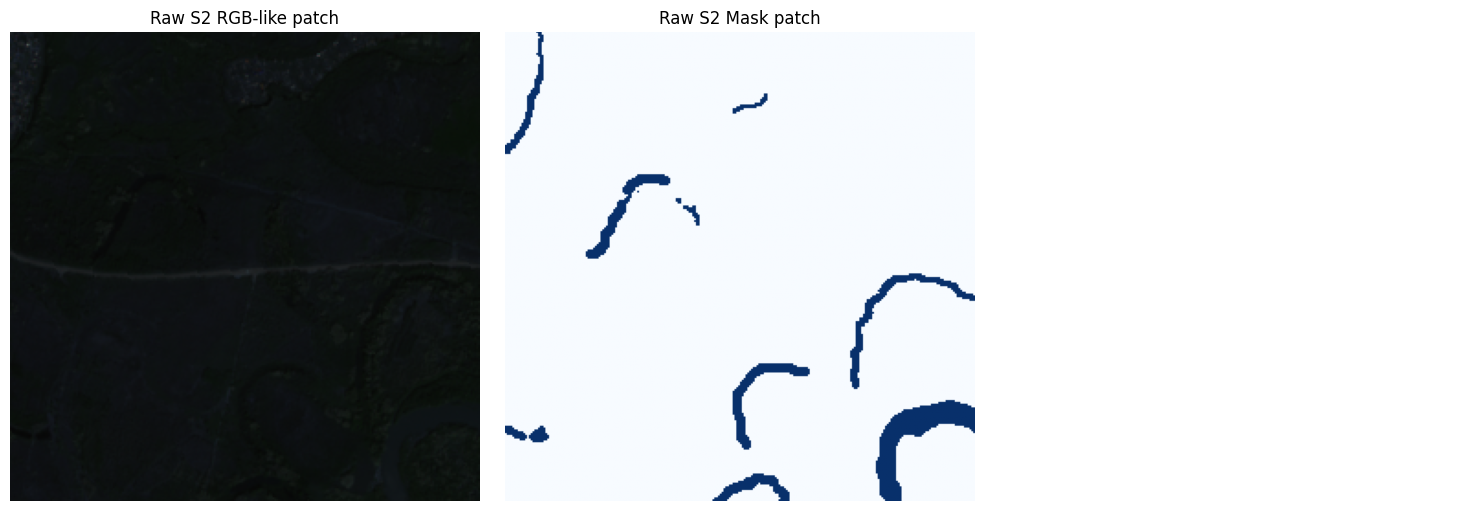

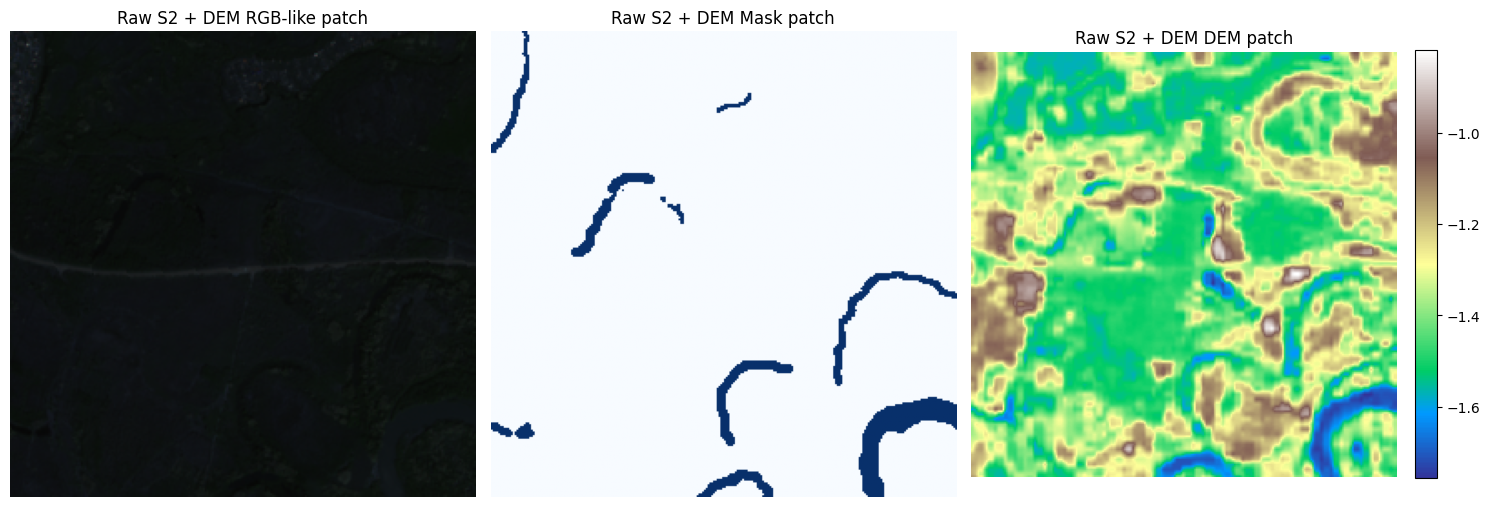

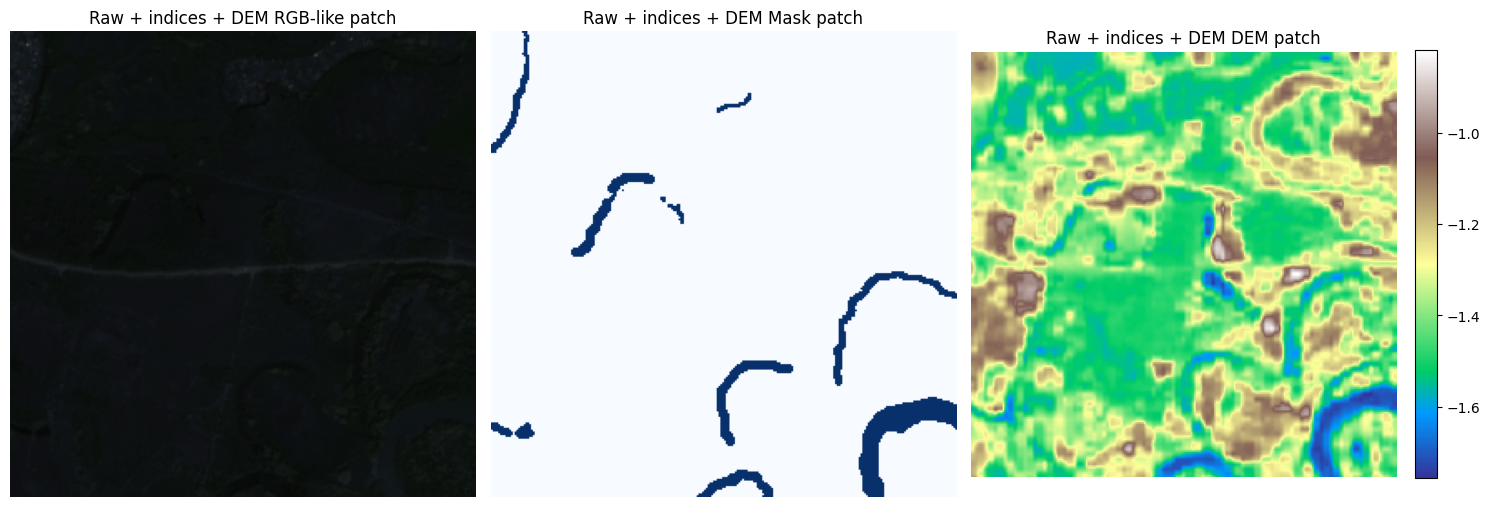

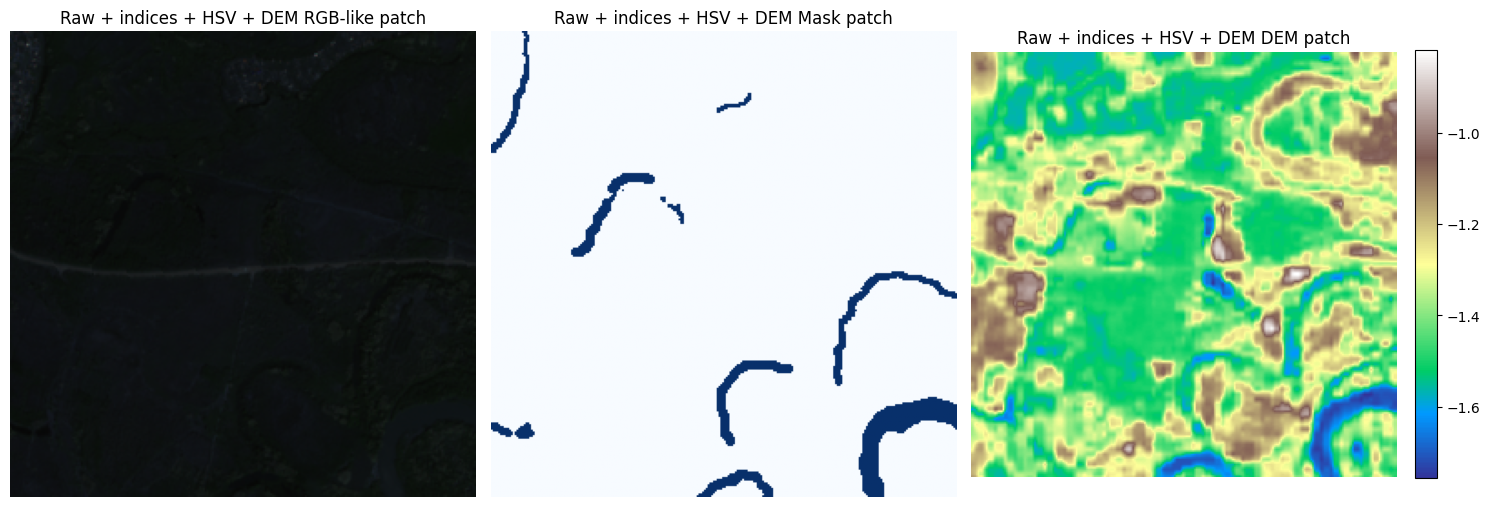

In [15]:
def show_patch(dataset, idx=0, title_prefix=""):
    x, y = dataset[idx]

    x_np = x.numpy()
    y_np = y.squeeze(0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # show first 3 channels for quick visualization
    rgb = np.transpose(x_np[:3], (1, 2, 0))
    rgb = np.clip(rgb, 0, 1)

    axes[0].imshow(rgb)
    axes[0].set_title(f"{title_prefix} RGB-like patch")
    axes[0].axis("off")

    axes[1].imshow(y_np, cmap="Blues")
    axes[1].set_title(f"{title_prefix} Mask patch")
    axes[1].axis("off")

    # show last channel only if this feature set includes DEM
    if dataset.feature_set in ["raw_s2_dem", "raw_idx_dem", "raw_idx_hsv_dem"]:
        dem = x_np[-1]
        im = axes[2].imshow(dem, cmap="terrain")
        axes[2].set_title(f"{title_prefix} DEM patch")
        axes[2].axis("off")
        plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    else:
        axes[2].axis("off")

    plt.tight_layout()
    plt.show()


show_patch(train_ds_raw, idx=0, title_prefix="Raw S2")
show_patch(train_ds_raw_dem, idx=0, title_prefix="Raw S2 + DEM")
show_patch(train_ds_idx, idx=0, title_prefix="Raw + indices + DEM")
show_patch(train_ds_hsv, idx=0, title_prefix="Raw + indices + HSV + DEM")

### NaN / inf check

In [16]:
def check_tensor_validity(dataset, idx=0, name="dataset"):
    x, y = dataset[idx]
    print(f"{name}")
    print("x has NaN:", torch.isnan(x).any().item())
    print("x has inf:", torch.isinf(x).any().item())
    print("y has NaN:", torch.isnan(y).any().item())
    print("y has inf:", torch.isinf(y).any().item())
    print()

check_tensor_validity(train_ds_raw, idx=0, name="Train raw S2 validity check")
check_tensor_validity(train_ds_raw_dem, idx=0, name="Train raw S2 + DEM validity check")
check_tensor_validity(train_ds_idx, idx=0, name="Train raw + indices + DEM validity check")
check_tensor_validity(train_ds_hsv, idx=0, name="Train raw + indices + HSV + DEM validity check")

Train raw S2 validity check
x has NaN: False
x has inf: False
y has NaN: False
y has inf: False

Train raw S2 + DEM validity check
x has NaN: False
x has inf: False
y has NaN: False
y has inf: False

Train raw + indices + DEM validity check
x has NaN: False
x has inf: False
y has NaN: False
y has inf: False

Train raw + indices + HSV + DEM validity check
x has NaN: False
x has inf: False
y has NaN: False
y has inf: False



### Value range check

In [17]:
def inspect_patch_stats(dataset, idx=0, name="dataset"):
    x, y = dataset[idx]
    print(f"{name}")
    print("x shape:", x.shape)
    print("y shape:", y.shape)
    print("x min :", x.min().item())
    print("x max :", x.max().item())
    print("x mean:", x.mean().item())
    print("x std :", x.std().item())
    print("y unique values:", torch.unique(y))
    print()

inspect_patch_stats(train_ds_raw, idx=0, name="Train raw S2 patch stats")
inspect_patch_stats(train_ds_raw_dem, idx=0, name="Train raw S2 + DEM patch stats")
inspect_patch_stats(train_ds_idx, idx=0, name="Train raw + indices + DEM patch stats")
inspect_patch_stats(train_ds_hsv, idx=0, name="Train raw + indices + HSV + DEM patch stats")

Train raw S2 patch stats
x shape: torch.Size([10, 256, 256])
y shape: torch.Size([1, 256, 256])
x min : 0.012600000016391277
x max : 0.34599998593330383
x mean: 0.12669172883033752
x std : 0.05581201985478401
y unique values: tensor([0., 1.])

Train raw S2 + DEM patch stats
x shape: torch.Size([11, 256, 256])
y shape: torch.Size([1, 256, 256])
x min : -1.7567505836486816
x max : 0.34599998593330383
x mean: -0.01003666315227747
x std : 0.4379481077194214
y unique values: tensor([0., 1.])

Train raw + indices + DEM patch stats
x shape: torch.Size([16, 256, 256])
y shape: torch.Size([1, 256, 256])
x min : -1.8986998796463013
x max : 0.6507208943367004
x mean: -0.11781734973192215
x std : 0.4261787533760071
y unique values: tensor([0., 1.])

Train raw + indices + HSV + DEM patch stats
x shape: torch.Size([19, 256, 256])
y shape: torch.Size([1, 256, 256])
x min : -1.8986998796463013
x max : 0.9973118305206299
x mean: -0.04597240313887596
x std : 0.43356120586395264
y unique values: tensor([

### Patch-level class imbalance check

In [18]:
def compute_dataset_class_balance(dataset, max_samples=None, name="dataset"):
    total_water = 0
    total_pixels = 0

    n = len(dataset) if max_samples is None else min(len(dataset), max_samples)

    for i in range(n):
        _, y = dataset[i]
        y_np = y.numpy()
        total_water += np.sum(y_np > 0)
        total_pixels += y_np.size

    water_pct = 100 * total_water / total_pixels
    nonwater_pct = 100 - water_pct

    print(name)
    print(f"Samples checked : {n}")
    print(f"Water %         : {water_pct:.4f}")
    print(f"Non-water %     : {nonwater_pct:.4f}")
    print()

compute_dataset_class_balance(train_ds_raw, max_samples=200, name="Train raw S2 patch-level class balance")
compute_dataset_class_balance(val_ds_raw, max_samples=200, name="Validation raw S2 patch-level class balance")

compute_dataset_class_balance(train_ds_raw_dem, max_samples=200, name="Train raw S2 + DEM patch-level class balance")
compute_dataset_class_balance(val_ds_raw_dem, max_samples=200, name="Validation raw S2 + DEM patch-level class balance")

compute_dataset_class_balance(train_ds_idx, max_samples=200, name="Train raw + indices + DEM patch-level class balance")
compute_dataset_class_balance(val_ds_idx, max_samples=200, name="Validation raw + indices + DEM patch-level class balance")

compute_dataset_class_balance(train_ds_hsv, max_samples=200, name="Train raw + indices + HSV + DEM patch-level class balance")
compute_dataset_class_balance(val_ds_hsv, max_samples=200, name="Validation raw + indices + HSV + DEM patch-level class balance")

Train raw S2 patch-level class balance
Samples checked : 200
Water %         : 2.0590
Non-water %     : 97.9410

Validation raw S2 patch-level class balance
Samples checked : 200
Water %         : 1.0482
Non-water %     : 98.9518

Train raw S2 + DEM patch-level class balance
Samples checked : 200
Water %         : 2.0590
Non-water %     : 97.9410

Validation raw S2 + DEM patch-level class balance
Samples checked : 200
Water %         : 1.0482
Non-water %     : 98.9518

Train raw + indices + DEM patch-level class balance
Samples checked : 200
Water %         : 2.0590
Non-water %     : 97.9410

Validation raw + indices + DEM patch-level class balance
Samples checked : 200
Water %         : 1.0482
Non-water %     : 98.9518

Train raw + indices + HSV + DEM patch-level class balance
Samples checked : 200
Water %         : 2.0590
Non-water %     : 97.9410

Validation raw + indices + HSV + DEM patch-level class balance
Samples checked : 200
Water %         : 1.0482
Non-water %     : 98.9518



### Save preprocessing metadata

In [19]:
import json

preprocessing_summary = {
    "patch_size": PATCH_SIZE,
    "stride": STRIDE,
    "batch_size": BATCH_SIZE,
    "multi_scale": float(10000.0),
    "dem_mean": float(dem_mean),
    "dem_std": float(dem_std),
    "train_scenes": [r.scene_id for r in train_records],
    "val_scenes": [r.scene_id for r in val_records],
    "test_scenes": [r.scene_id for r in test_records],
    "train_patches": len(train_index),
    "val_patches": len(val_index),
    "test_patches": len(test_index),
    "feature_sets": {
        "raw_s2": 10,
        "raw_s2_dem": 11,
        "raw_idx_dem": 16,
        "raw_idx_hsv_dem": 19,
    },
    "indices": ["NDWI", "MNDWI", "SWI", "AWEIsh", "AWEInsh"],
    "hsv_definition": "HSV from SWIR2,NIR,Red mapped to RGB, following NASA flood paper",
}

print(preprocessing_summary)

with open("step2_preprocessing_summary.json", "w") as f:
    json.dump(preprocessing_summary, f, indent=2)

print("\nSaved preprocessing summary to step2_preprocessing_summary.json")

{'patch_size': 256, 'stride': 256, 'batch_size': 4, 'multi_scale': 10000.0, 'dem_mean': 151.59597778320312, 'dem_std': 39.80539321899414, 'train_scenes': ['1_train', '2_train'], 'val_scenes': ['1_val', '2_val'], 'test_scenes': ['3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], 'train_patches': 1200, 'val_patches': 520, 'test_patches': 834, 'feature_sets': {'raw_s2': 10, 'raw_s2_dem': 11, 'raw_idx_dem': 16, 'raw_idx_hsv_dem': 19}, 'indices': ['NDWI', 'MNDWI', 'SWI', 'AWEIsh', 'AWEInsh'], 'hsv_definition': 'HSV from SWIR2,NIR,Red mapped to RGB, following NASA flood paper'}

Saved preprocessing summary to step2_preprocessing_summary.json


## Save artifacts for future steps

This section saves the patch indices and preprocessing configuration so that later notebooks
(such as Step 3 training and Step 4 evaluation) can reconstruct the datasets without
re-running the entire preprocessing pipeline.

In [20]:
import json
import pickle
from pathlib import Path

ARTIFACTS_DIR = Path("step2_artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Save patch indices
with open(ARTIFACTS_DIR / "train_index.pkl", "wb") as f:
    pickle.dump(train_index, f)

with open(ARTIFACTS_DIR / "val_index.pkl", "wb") as f:
    pickle.dump(val_index, f)

with open(ARTIFACTS_DIR / "test_index.pkl", "wb") as f:
    pickle.dump(test_index, f)

# Save reusable preprocessing/configuration info
step2_bundle = {
    "data_dir": str(DATA_DIR),
    "multi_dir": str(MULTI_DIR),
    "dem_dir": str(DEM_DIR),
    "mask_dir": str(MASK_DIR),
    "patch_size": PATCH_SIZE,
    "stride": STRIDE,
    "batch_size": BATCH_SIZE,
    "multi_scale": float(10000.0),
    "dem_mean": float(dem_mean),
    "dem_std": float(dem_std),
    "band_names": BAND_NAMES,
    "band_to_idx": BAND_TO_IDX,
    "train_scenes": [r.scene_id for r in train_records],
    "val_scenes": [r.scene_id for r in val_records],
    "test_scenes": [r.scene_id for r in test_records],
    "feature_sets": {
        "raw_s2": 10,
        "raw_s2_dem": 11,
        "raw_idx_dem": 16,
        "raw_idx_hsv_dem": 19,
    },
    "indices": ["NDWI", "MNDWI", "SWI", "AWEIsh", "AWEInsh"],
    "hsv_definition": "HSV from SWIR2,NIR,Red mapped to RGB, following NASA flood paper",
}

with open(ARTIFACTS_DIR / "step2_bundle.json", "w") as f:
    json.dump(step2_bundle, f, indent=2)

print("Saved Step 2 artifacts to:", ARTIFACTS_DIR.resolve())
print("Files created:")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(" -", p.name)

with open(ARTIFACTS_DIR / "step2_bundle.json", "r") as f:
    saved_bundle = json.load(f)

print("Loaded saved bundle successfully.")
print("Patch size:", saved_bundle["patch_size"])
print("Batch size:", saved_bundle["batch_size"])
print("Train scenes:", saved_bundle["train_scenes"])
print("Val scenes:", saved_bundle["val_scenes"])
print("Test scenes:", saved_bundle["test_scenes"])
print("Feature sets:", saved_bundle["feature_sets"])

Saved Step 2 artifacts to: C:\Users\wattd\OneDrive\Desktop\flood-segmentation\step2_artifacts
Files created:
 - step2_bundle.json
 - test_index.pkl
 - train_index.pkl
 - val_index.pkl
Loaded saved bundle successfully.
Patch size: 256
Batch size: 4
Train scenes: ['1_train', '2_train']
Val scenes: ['1_val', '2_val']
Test scenes: ['3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
Feature sets: {'raw_s2': 10, 'raw_s2_dem': 11, 'raw_idx_dem': 16, 'raw_idx_hsv_dem': 19}


### Conclusions

Data preprocessing was designed to preserve the predefined scene-level train/validation/test split. Multispectral inputs, DEM, and masks were aligned using the mask raster as the spatial reference. Because the multispectral scenes `1.tif` and `2.tif` were provided as full scenes while DEM and masks included cropped train/validation subsets (`1_train`, `1_val`, `2_train`, `2_val`), the corresponding multispectral regions were extracted by geographic bounds to match the supervision rasters. Inputs were then converted into fixed-size 256×256 patches for model training.

Multispectral bands were scaled by 10000, while DEM values were standardized using training-set statistics. Four dataset variants were prepared: raw Sentinel-2 only, raw Sentinel-2 plus DEM, raw Sentinel-2 plus engineered spectral indices and DEM, and raw Sentinel-2 plus engineered spectral indices, NASA-style HSV features, and DEM.

Following the confirmed Sentinel-2 band order and the chosen water-index formulations, spectral indices were computed explicitly as NDWI, MNDWI, SWI, AWEIsh, and AWEInsh. HSV was computed from SWIR2, NIR, and Red before conversion, following the NASA flood paper.